In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
def data1():
    X=pd.read_csv('nifty.csv')
    X['c-o']=(X.Close-X.Open)/X.Open*100
    X['candle']=np.where(X['c-o'].values<-1,0,np.where(X['c-o'].values<-0.5,1,np.where(X['c-o'].values<0,2,np.where(X['c-o'].values<0.5,3,np.where(X['c-o'].values<1,4,5)))))
    X = X.dropna(axis = 0, how ='any')
    X = X.reset_index()
    X['cashopen']=0
    X['cash']=0
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [3]:
X=data1()
print(len(X))

2945


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\IIITNAGPUR\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


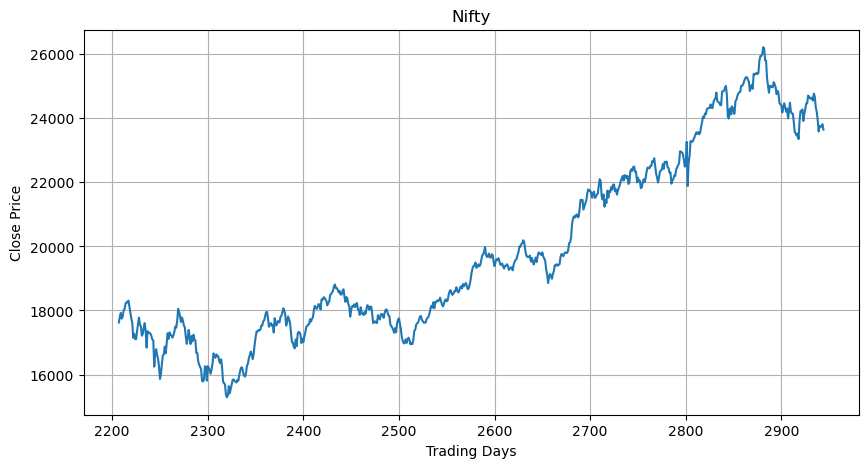

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
%pylab inline
fig = plt.figure()
ax=X.loc[2207:len(X),'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [5]:
len(X)-2207

738

In [6]:
X['candle'].value_counts()

candle
2    837
3    808
1    432
4    361
0    296
5    211
Name: count, dtype: int64

In [7]:
#X.head()

In [8]:
def getState(t):    
    return(X['candle'][t])  

In [9]:
class Agent:
    def __init__(self):
           
        self.gamma = np.load('rl/gamma100.npy')
        self.Q = np.load('rl/Qtable100.npy')
        self.learning_rate=np.load('rl/learning_rate100.npy')
        self.epsilon = np.load('rl/epsilon100.npy')
        print(self.epsilon)
    def getAction(self,state):
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
            self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [10]:
episode_count=1
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=2207
    data_length=2944
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    X.loc[2,'cashopen']=margin 
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
       
        elif action == 2:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t)
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n")
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
       
    
    m3=roi
    if m3>m2:
          m1=e
          m2=m3
        #To save model  
    if e%1==0:
            np.save('rl/test/Qtable'+ str(e)+str('.npy'), agent.Q)
            np.save('rl/test/epsilon'+ str(e)+str('.npy'), agent.epsilon)
            np.save('rl/test/gamma'+ str(e)+str('.npy'), agent.gamma)
            np.save('rl/test/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
            X.to_csv('csv1/AfterTest'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

0.00998645168764533
Episod 1/50

***********************

Profit is  20159.190490000532
Initial Capital is  173871.50389999998
Current Capital is  194030.6943900005
%ROI is  11.59430386108286
% Buy and Hold= 36.95976543514558
count 737
qtable [[0.00591472 0.00791422 0.00843966]
 [0.00577061 0.0070071  0.00751854]
 [0.00570287 0.00675976 0.00647278]
 [0.00584601 0.00655453 0.0085489 ]
 [0.00540446 0.00735133 0.00726777]
 [0.00556566 0.00807885 0.00950998]]
epsilon 0.00998645168764533
--------------------------------
Episod 2/50

***********************

Profit is  10255.523119999678
Initial Capital is  173871.50389999998
Current Capital is  184127.02701999966
%ROI is  5.898334626413546
% Buy and Hold= 36.95976543514558
count 737
qtable [[0.00591472 0.00822432 0.00777611]
 [0.00577061 0.00654045 0.00691571]
 [0.00570287 0.00628261 0.00589843]
 [0.00584601 0.00630851 0.00815812]
 [0.00540446 0.00695895 0.00683756]
 [0.00556566 0.00807885 0.00858668]]
epsilon 0.00998645168764533
----------

In [11]:
agent.Q

array([[0.00591472, 0.00903013, 0.00777611],
       [0.00577061, 0.00644679, 0.00701801],
       [0.00544213, 0.00549098, 0.00739434],
       [0.00584601, 0.00608204, 0.00844191],
       [0.00540446, 0.00680304, 0.00622169],
       [0.00556566, 0.00807885, 0.00839242]])

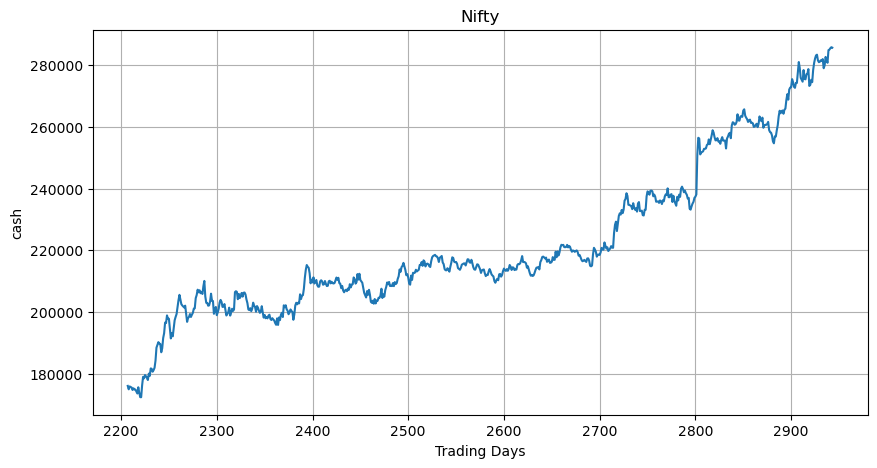

In [12]:
%matplotlib inline
#%pylab inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-1,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()
#fig.savefig('baroda_close.png')